# Proiect: Detectarea Anomaliilor în Performanța Jucătorilor NBA

## 1. Descrierea Problemei
Scopul acestui proiect este construirea și evaluarea unui sistem de detectare a anomaliilor pentru un set de date real, utilizând framework-ul **PyOD**.
În contextul NBA, o "anomalie" nu reprezintă o eroare de date, ci un jucător cu performanțe atipice – fie un superstar cu statistici mult peste medie, fie un jucător cu un profil de joc unic.

**Tipul Anomaliilor:**
În acest set de date, ne concentrăm preponderent pe detectarea **anomaliilor globale (Point Anomalies)**. Acestea sunt observații (jucători) care deviază semnificativ de la restul setului de date în totalitatea sa (de exemplu, un jucător care are valori extreme la toate capitolele).
Totuși, metodele precum KNN pot detecta și **anomalii locale**, adică jucători care sunt atipici doar raportat la vecinătatea lor imediată (de exemplu, un jucător cu profil defensiv care marchează neobișnuit de mult), deși în contextul NBA distincția majoră rămâne între "jucători medii" (clusterul principal) și "jucători de elită" (outlieri globali).

Obiectivul este de a identifica acești jucători folosind metode nesupervizate și de a explica statistic de ce au fost selectați.

## 2. Descrierea Setului de Date
Vom utiliza statistici oficiale ale jucătorilor din sezonul NBA 2024-2025. Datele au fost extrase de pe platforma **Basketball Reference** și conțin informații detaliate despre performanța individuală.

* **Sursă date:** [Basketball Reference - 2025 Per Game Stats](https://www.basketball-reference.com/leagues/NBA_2025_per_game.html)
* **Format:** Fișier CSV cu statistici per meci.

**Variabilele principale analizate sunt:**
* **PTS:** Puncte marcate pe meci.
* **AST:** Pase decisive.
* **TRB:** Total recuperări.
* **BLK/STL:** Capace și Intercepții.

*Notă:* Deoarece algoritmii de detecție a anomaliilor sunt sensibili la scara datelor (punctele au valori mari, intercepțiile valori mici), vom aplica o etapă riguroasă de **preprocesare** (curățare valori lipsă și normalizare).

In [ ]:
!pip install pyod

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
from pyod.utils.data import evaluate_print

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 11.5 MB/s eta 0:00:00


## 2. Încărcarea și Preprocesarea Datelor
În această etapă realizăm pregătirea datelor pentru modelare:
1. **Selecția variabilelor:** Ne concentrăm pe statisticile cheie de performanță (PTS, AST, TRB, BLK, STL).
2. **Normalizarea:** Aplicăm `MinMaxScaler` pentru a scala toate valorile în intervalul [0, 1], asigurând că nicio variabilă nu domină calculul distanțelor.
3. **Reducerea dimensionalității:** Aplicăm PCA pentru a proiecta datele într-un spațiu 2D, facilitând vizualizarea ulterioară a distribuției și a anomaliilor.

In [ ]:
df = pd.read_csv('datetema2.csv')

features = ['PTS', 'AST', 'TRB', 'BLK', 'STL']
X = df[features].fillna(0)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_scaled_df.head())

        PTS       AST       TRB       BLK       STL
0  1.000000  0.551724  0.359712  0.263158  0.566667
1  0.929664  0.560345  0.856115  0.315789  0.300000
2  0.905199  0.879310  0.913669  0.157895  0.600000
3  0.862385  0.663793  0.589928  0.105263  0.600000
4  0.844037  0.387931  0.410072  0.157895  0.400000


## 3. Explorarea Datelor (EDA)
În această etapă, vizualizăm distribuția variabilelor individuale folosind histograme pentru a înțelege tiparele generale. Ne așteptăm ca distribuțiile să nu fie Gaussiene perfecte, ci asimetrice (skewed), deoarece performanțele de elită sunt rare.

De asemenea, vizualizăm proiecția datelor în spațiul 2D obținut prin PCA (Principal Component Analysis). Aceasta ne oferă o imagine de ansamblu asupra structurii datelor și ne ajută să intuim vizual existența unor puncte izolate (anomalii) înainte de aplicarea algoritmilor.

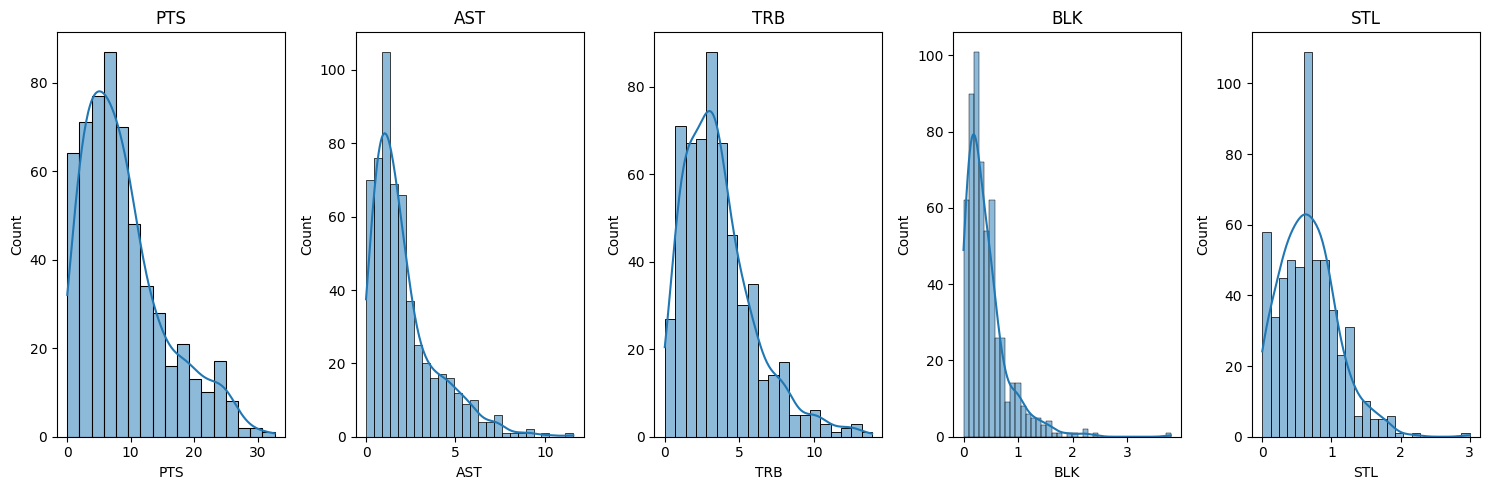

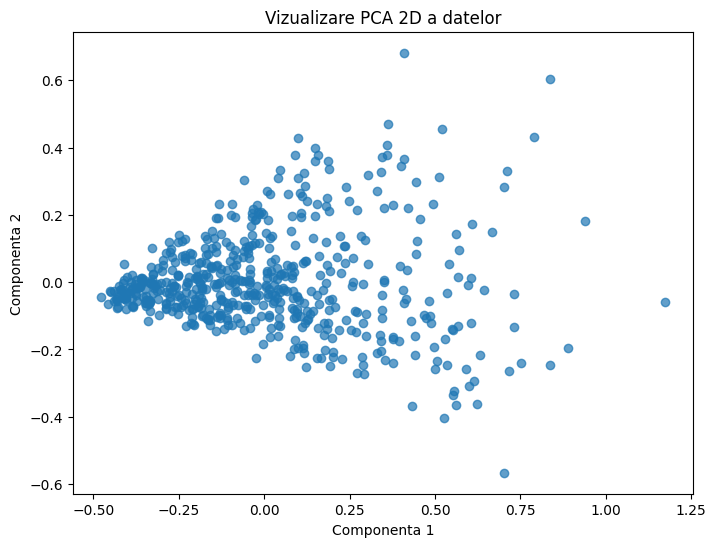

In [ ]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 5, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.title('Vizualizare PCA 2D a datelor')
plt.xlabel('Componenta 1')
plt.ylabel('Componenta 2')
plt.show()

### Interpretarea Graficelor

**1. Histogramele (Distribuția Variabilelor):**
Graficele de sus arată frecvența valorilor pentru fiecare statistică (PTS, AST, etc.).
* **Observație:** Majoritatea distribuțiilor sunt **asimetrice la dreapta (right-skewed)**.
* **Semnificație:** "Cocoașa" mare din stânga reprezintă majoritatea jucătorilor din ligă, care au performanțe medii sau scăzute. "Coada" lungă care se întinde spre dreapta reprezintă numărul mic de jucători cu valori extreme (foarte mari).
* **Concluzie pentru proiect:** Această "coadă" este exact zona unde ne așteptăm să găsim anomaliile (superstarurile). Dacă datele ar fi urmat o distribuție normală perfectă (clopot Gauss), anomaliile ar fi fost mult mai greu de distins.

**2. Graficul PCA 2D:**
Graficul de jos reprezintă o proiecție a tuturor celor 5 dimensiuni (statistici) într-un spațiu bidimensional.
* **Observație:** Se observă un **cluster dens** (aglomerare de puncte) într-o anumită zonă și mai multe puncte dispersate (răzlețe) în afara acestuia.
* **Semnificație:** Clusterul dens reprezintă profilul jucătorului standard NBA. Punctele care se află la distanță mare de acest nucleu sugerează existența unor instanțe care deviază semnificativ de la normă.
* **Validare:** Faptul că vedem vizual puncte izolate justifică utilizarea algoritmilor de detecție a anomaliilor (precum KNN sau IForest) pe acest set de date.

## 4. Metodologie și Algoritmi
Pentru o analiză robustă, vom implementa trei metode diferite de detecție a anomaliilor, din categorii distincte:

1.  **KNN (K-Nearest Neighbors):**
    * *Tip:* Bazat pe distanță.
    * *Funcționare:* Pentru fiecare punct, calculează distanța până la cei mai apropiați *k* vecini. Punctele cu distanțe mari sunt considerate anomalii (izolate).

2.  **ABOD (Angle-Based Outlier Detection):**
    * *Tip:* Probabilistic/Geometric.
    * *Funcționare:* Analizează varianța unghiurilor dintre un punct și restul punctelor. Punctele izolate au o varianță mică a unghiurilor.

3.  **Isolation Forest (IForest):**
    * *Tip:* Bazat pe ansambluri de arbori (Ensemble).
    * *Funcționare:* Izolează observațiile prin selectarea aleatorie a unei caracteristici. Anomaliile sunt izolate mai repede (au o adâncime mai mică în arbore) decât punctele normale.

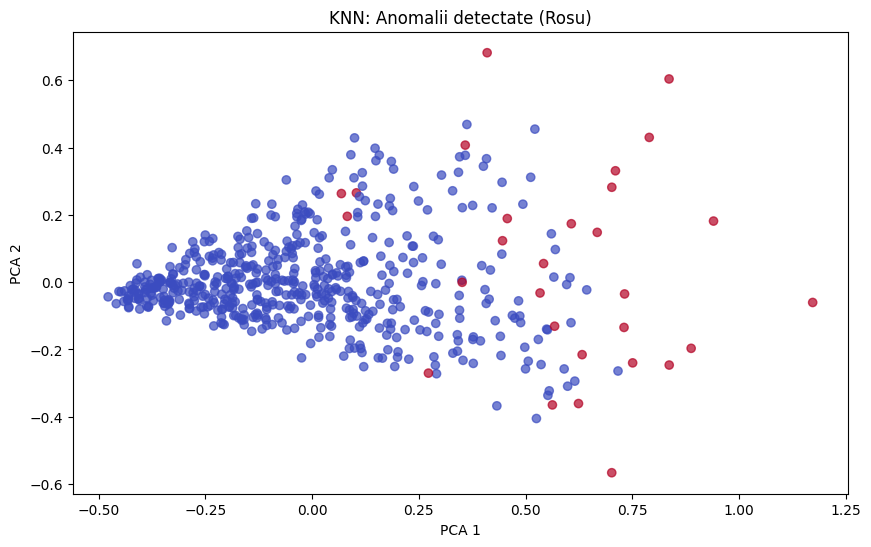

Jucători detectați ca anomalii de KNN:
                     Player   PTS   AST   TRB
0   Shai Gilgeous-Alexander  32.7   6.4   5.0
1     Giannis Antetokounmpo  30.4   6.5  11.9
2              Nikola Jokić  29.6  10.2  12.7
3               Luka Dončić  28.2   7.7   8.2
5              Jayson Tatum  26.8   6.0   8.7
7              Tyrese Maxey  26.3   6.1   3.3
8           Cade Cunningham  26.1   9.1   6.1
14            Anthony Davis  24.7   3.5  11.6
18             LeBron James  24.4   8.2   7.8
19       Karl-Anthony Towns  24.4   3.1  12.8


In [ ]:
contamination = 0.05
knn = KNN(contamination=contamination)
knn.fit(X_scaled)

y_train_pred_knn = knn.labels_
y_train_scores_knn = knn.decision_scores_

anomalies_knn = df.iloc[np.where(y_train_pred_knn == 1)]

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_pred_knn, cmap='coolwarm', alpha=0.7)
plt.title('KNN: Anomalii detectate (Rosu)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

print("Jucători detectați ca anomalii de KNN:")
print(anomalies_knn[['Player', 'PTS', 'AST', 'TRB']].head(10))

### 4.2. Modelul 2: ABOD (Angle-Based Outlier Detection)
După analiza bazată pe distanță (KNN), aplicăm o metodă geometrică. ABOD analizează unghiurile dintre puncte pentru a determina dacă un jucător este "izolat" în spațiul vectorial, oferind o perspectivă complementară.

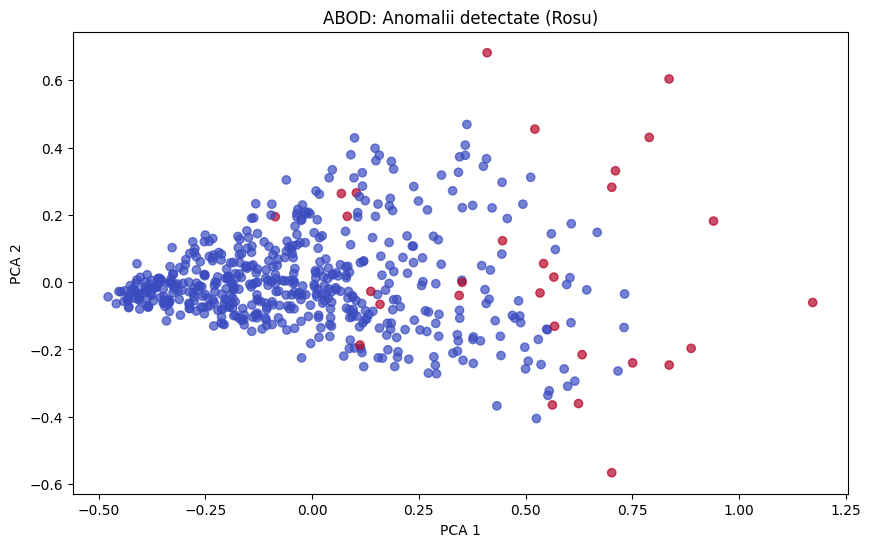

Jucători detectați ca anomalii de ABOD:
                     Player   PTS   AST   TRB
0   Shai Gilgeous-Alexander  32.7   6.4   5.0
1     Giannis Antetokounmpo  30.4   6.5  11.9
2              Nikola Jokić  29.6  10.2  12.7
3               Luka Dončić  28.2   7.7   8.2
6              Kevin Durant  26.6   4.2   6.0
7              Tyrese Maxey  26.3   6.1   3.3
8           Cade Cunningham  26.1   9.1   6.1
14            Anthony Davis  24.7   3.5  11.6
19       Karl-Anthony Towns  24.4   3.1  12.8
20        Victor Wembanyama  24.3   3.7  11.0


In [ ]:
abod = ABOD(contamination=contamination)
abod.fit(X_scaled)

y_train_pred_abod = abod.labels_
y_train_scores_abod = abod.decision_scores_

anomalies_abod = df.iloc[np.where(y_train_pred_abod == 1)]

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_pred_abod, cmap='coolwarm', alpha=0.7)
plt.title('ABOD: Anomalii detectate (Rosu)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

print("Jucători detectați ca anomalii de ABOD:")
print(anomalies_abod[['Player', 'PTS', 'AST', 'TRB']].head(10))

### 4.3. Modelul 3: Isolation Forest
Ultimul algoritm aplicat este Isolation Forest. Această metodă este foarte eficientă pe seturi de date reale deoarece "izolează" anomaliile rapid (prin puține decizii în arbore), spre deosebire de punctele normale care sunt mai greu de izolat.

In [ ]:
from pyod.models.iforest import IForest

clf_if = IForest(contamination=contamination, random_state=42)
clf_if.fit(X_scaled)

y_pred_if = clf_if.labels_
scores_if = clf_if.decision_scores_

anomalies_if = df.iloc[np.where(y_pred_if == 1)]

print(f"Număr anomalii detectate de IForest: {len(anomalies_if)}")
print(anomalies_if[['Player', 'PTS']].head())

sil_if = silhouette_score(X_scaled, y_pred_if)
print(f"Silhouette Score IForest: {sil_if:.4f}")

Număr anomalii detectate de IForest: 29
                    Player   PTS
0  Shai Gilgeous-Alexander  32.7
1    Giannis Antetokounmpo  30.4
2             Nikola Jokić  29.6
3              Luka Dončić  28.2
6             Kevin Durant  26.6
Silhouette Score IForest: 0.4692


## 5. Interpretarea Rezultatelor
Simplul fapt că un algoritm etichetează un jucător ca "anomalie" nu este suficient. Mai jos, analizăm **cauzele** statistice.
Comparăm valorile jucătorilor detectați cu media ligii pentru a înțelege exact la ce capitole excelează (ex: Puncte, Recuperări).

In [ ]:
import plotly.express as px

df_plot = df.copy()
df_plot['Anomaly_KNN'] = y_train_pred_knn
df_plot['Anomaly_KNN_Label'] = df_plot['Anomaly_KNN'].apply(lambda x: 'Anomalie' if x == 1 else 'Normal')
df_plot['PCA1'] = X_pca[:, 0]
df_plot['PCA2'] = X_pca[:, 1]

fig = px.scatter(df_plot,
                 x='PCA1',
                 y='PCA2',
                 color='Anomaly_KNN_Label',
                 hover_data=['Player', 'PTS', 'AST', 'TRB', 'Team'],
                 title='Vizualizare Interactivă a Anomaliilor (KNN)',
                 color_discrete_map={'Normal': 'blue', 'Anomalie': 'red'})

fig.show()

## 6. Evaluarea Performanței
Deoarece nu avem etichete reale ("ground truth") despre cine este oficial anomalie, folosim metrici interne de validare a clusterelor:

1.  **Scorul Silhouette:** Măsoară cât de similar este un obiect cu propriul cluster (normal) comparativ cu alte clustere (anomalii). Valori mai mari indică o separare mai bună.
2.  **Indicele Dunn:** Evaluează raportul dintre cea mai mică distanță inter-cluster și cel mai mare diametru intra-cluster.

### 6.1. Optimizarea Parametrilor (KNN)
Înainte de a trage concluzii finale, verificăm stabilitatea modelului KNN. Rulăm algoritmul pentru diferite valori ale lui `k` (numărul de vecini) și monitorizăm scorul Silhouette.
Scopul este să găsim o valoare `k` unde scorul este maxim, indicând cea mai clară separare a anomaliilor.

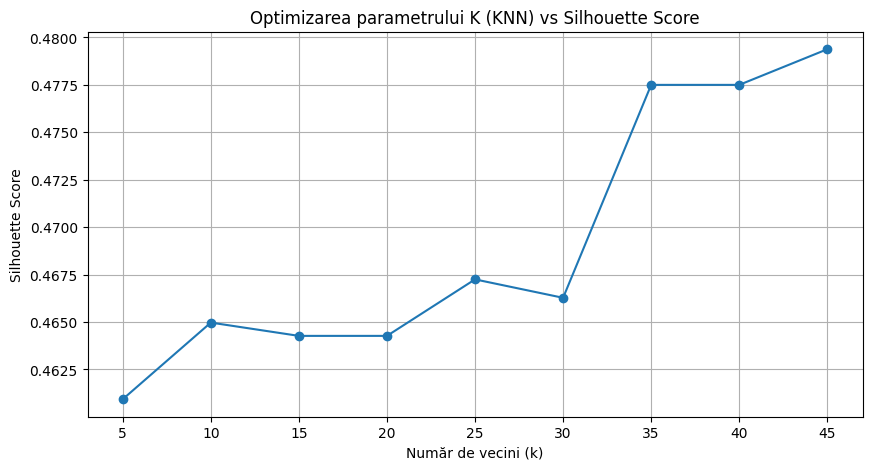

In [ ]:
k_range = range(5, 50, 5)
silhouette_scores = []

for k in k_range:
    clf = KNN(n_neighbors=k, contamination=0.05)
    clf.fit(X_scaled)
    labels = clf.labels_
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X_scaled, labels))
    else:
        silhouette_scores.append(0)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Optimizarea parametrului K (KNN) vs Silhouette Score')
plt.xlabel('Număr de vecini (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### 6.2. Comparația Finală a Modelelor (Metrici)
Calculăm scorul Silhouette pentru toate cele trei modele (KNN, ABOD, IForest) pe întregul set de date.
Algoritmul care obține cel mai mare scor este considerat cel mai performant în separarea "superstarurilor" de jucătorii obișnuiți.
De asemenea, identificăm **consensul**: jucătorii care au fost detectați ca anomalii de toate cele trei metode simultan. Aceștia reprezintă anomaliile cu cel mai înalt grad de certitudine.

In [ ]:
sil_knn = silhouette_score(X_scaled, y_train_pred_knn)
sil_abod = silhouette_score(X_scaled, y_train_pred_abod)
sil_if = silhouette_score(X_scaled, y_pred_if)

print(f"Silhouette Score KNN: {sil_knn:.4f}")
print(f"Silhouette Score ABOD: {sil_abod:.4f}")
print(f"Silhouette Score IForest: {sil_if:.4f}")

scores = {'KNN': sil_knn, 'ABOD': sil_abod, 'IForest': sil_if}
best_model = max(scores, key=scores.get)
print(f"\nCel mai bun model (conform Silhouette) este: {best_model} cu scorul {scores[best_model]:.4f}")

common_players = set(anomalies_knn['Player']) & set(anomalies_abod['Player']) & set(anomalies_if['Player'])
common_anomalies = df[df['Player'].isin(common_players)]

print(f"\nNumăr anomalii comune detectate de toate cele 3 modele: {len(common_anomalies)}")
print("Exemple de jucători detectați de toate modelele:")
print(common_anomalies[['Player', 'PTS', 'AST', 'TRB']].head(10))

Silhouette Score KNN: 0.4609
Silhouette Score ABOD: 0.4366
Silhouette Score IForest: 0.4692

Cel mai bun model (conform Silhouette) este: IForest cu scorul 0.4692

Număr anomalii comune detectate de toate cele 3 modele: 20
Exemple de jucători detectați de toate modelele:
                     Player   PTS   AST   TRB
0   Shai Gilgeous-Alexander  32.7   6.4   5.0
1     Giannis Antetokounmpo  30.4   6.5  11.9
2              Nikola Jokić  29.6  10.2  12.7
3               Luka Dončić  28.2   7.7   8.2
7              Tyrese Maxey  26.3   6.1   3.3
8           Cade Cunningham  26.1   9.1   6.1
14            Anthony Davis  24.7   3.5  11.6
19       Karl-Anthony Towns  24.4   3.1  12.8
20        Victor Wembanyama  24.3   3.7  11.0
22               Trae Young  24.2  11.6   3.1


### 6.3. Evaluare Suplimentară: Indicele Dunn
Calculăm și Indicele Dunn pentru a avea o a doua opinie asupra calității clusterelor.
Deși scorul Silhouette este principala noastră metrică, Indicele Dunn ne ajută să înțelegem raportul dintre separarea clusterelor și compactitatea lor.

In [ ]:
from sklearn.metrics import pairwise_distances

def dunn_index(X, labels):
    if len(np.unique(labels)) < 2:
        return 0

    distances = pairwise_distances(X)
    unique_labels = np.unique(labels)

    diameters = []
    for label in unique_labels:
        cluster_points = np.where(labels == label)[0]
        if len(cluster_points) > 1:
            cluster_dist = distances[np.ix_(cluster_points, cluster_points)]
            diameters.append(cluster_dist.max())
        else:
            diameters.append(0)
    max_diameter = max(diameters) if diameters else 1

    min_inter_dists = []
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            c1 = np.where(labels == unique_labels[i])[0]
            c2 = np.where(labels == unique_labels[j])[0]
            dist = distances[np.ix_(c1, c2)]
            min_inter_dists.append(dist.min())

    min_inter = min(min_inter_dists) if min_inter_dists else 0

    return min_inter / max_diameter

dunn_knn = dunn_index(X_scaled, y_train_pred_knn)
dunn_abod = dunn_index(X_scaled, y_train_pred_abod)
dunn_if = dunn_index(X_scaled, y_pred_if)

print(f"Dunn Index KNN: {dunn_knn:.4f}")
print(f"Dunn Index ABOD: {dunn_abod:.4f}")
print(f"Dunn Index IForest: {dunn_if:.4f}")

Dunn Index KNN: 0.0816
Dunn Index ABOD: 0.1006
Dunn Index IForest: 0.0712


### 7. Rezultate Detaliate
Mai jos listăm concret jucătorii identificați de fiecare algoritm, precum și intersecția celor două/trei mulțimi.

In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)

common_players = np.intersect1d(anomalies_knn['Player'], anomalies_abod['Player'])

common_anomalies = df[df['Player'].isin(common_players)]

print("--- Toate anomaliile detectate de KNN ---")
print(anomalies_knn[['Player', 'PTS', 'AST', 'TRB']])

print("\n--- Toate anomaliile detectate de ABOD ---")
print(anomalies_abod[['Player', 'PTS', 'AST', 'TRB']])

print(f"\n--- Toate anomaliile comune ({len(common_anomalies)} jucători) ---")
print(common_anomalies[['Player', 'PTS', 'AST', 'TRB']])

--- Toate anomaliile detectate de KNN ---
                      Player   PTS   AST   TRB
0    Shai Gilgeous-Alexander  32.7   6.4   5.0
1      Giannis Antetokounmpo  30.4   6.5  11.9
2               Nikola Jokić  29.6  10.2  12.7
3                Luka Dončić  28.2   7.7   8.2
5               Jayson Tatum  26.8   6.0   8.7
7               Tyrese Maxey  26.3   6.1   3.3
8            Cade Cunningham  26.1   9.1   6.1
14             Anthony Davis  24.7   3.5  11.6
18              LeBron James  24.4   8.2   7.8
19        Karl-Anthony Towns  24.4   3.1  12.8
20         Victor Wembanyama  24.3   3.7  11.0
22                Trae Young  24.2  11.6   3.1
34         Jaren Jackson Jr.  22.2   2.0   5.6
54          Domantas Sabonis  19.1   6.0  13.9
55            Alperen Şengün  19.1   4.9  10.3
58             Jalen Johnson  18.9   5.0  10.0
61         Tyrese Haliburton  18.6   9.2   3.5
73           Dejounte Murray  17.5   7.4   6.5
94             Chet Holmgren  15.0   2.0   8.0
100              J

**Analiza Procentuală a Tuturor Anomaliilor Comune:**

In [ ]:
import pandas as pd
import numpy as np

anomalies_to_explain = common_anomalies.copy()
numeric_cols = ['PTS', 'AST', 'TRB', 'BLK', 'STL']

global_means = df[numeric_cols].mean()

def explain_anomaly(player_row, means):
    player_name = player_row['Player']
    diffs = {}

    for col in numeric_cols:
        val = player_row[col]
        mean_val = means[col]
        diff = val - mean_val
        percent_diff = (diff / mean_val) * 100
        diffs[col] = (val, mean_val, percent_diff)

    sorted_diffs = sorted(diffs.items(), key=lambda x: x[1][2], reverse=True)

    top_3_reasons = sorted_diffs[:3]

    print(f"\nJucător: {player_name}")
    print(f"{'Statistica':<10} | {'Valoare':<8} | {'Media Ligii':<12} | {'Deviație'}")
    print("-" * 50)

    for feature, (val, mean, pct) in top_3_reasons:
        print(f"{feature:<10} | {val:<8.1f} | {mean:<12.1f} | +{pct:.0f}% peste medie")

print(f"--- ANALIZA CAUZELOR PENTRU {len(anomalies_to_explain)} JUCĂTORI COMUNI ---")
for index, row in anomalies_to_explain.iterrows():
    explain_anomaly(row, global_means)

--- ANALIZA CAUZELOR PENTRU 22 JUCĂTORI COMUNI ---

Jucător: Shai Gilgeous-Alexander
Statistica | Valoare  | Media Ligii  | Deviație
--------------------------------------------------
PTS        | 32.7     | 8.9          | +268% peste medie
AST        | 6.4      | 2.1          | +207% peste medie
STL        | 1.7      | 0.7          | +154% peste medie

Jucător: Giannis Antetokounmpo
Statistica | Valoare  | Media Ligii  | Deviație
--------------------------------------------------
PTS        | 30.4     | 8.9          | +242% peste medie
TRB        | 11.9     | 3.6          | +231% peste medie
AST        | 6.5      | 2.1          | +212% peste medie

Jucător: Nikola Jokić
Statistica | Valoare  | Media Ligii  | Deviație
--------------------------------------------------
AST        | 10.2     | 2.1          | +389% peste medie
TRB        | 12.7     | 3.6          | +253% peste medie
PTS        | 29.6     | 8.9          | +233% peste medie

Jucător: Luka Dončić
Statistica | Valoare  | Medi

### 8. Interpretarea și Vizualizarea Cauzelor
Pentru a valida rezultatele, generăm o analiză vizuală pentru top 3 cele mai proeminente anomalii comune.
Graficele de mai jos compară performanța fiecărui jucător detectat (bara roșie) cu media ligii (bara gri) pentru fiecare statistică. Acest lucru ne arată imediat **de ce** un jucător a fost clasificat ca anomalie (de exemplu: are un număr de puncte sau pase dublu față de medie).


--- ANALIZĂ: Shai Gilgeous-Alexander ---
Statistica | Valoare Jucător | Media Ligii | Diferență
-------------------------------------------------------
PTS        | 32.7            | 8.9         | +267.9%
AST        | 6.4             | 2.1         | +206.9%
TRB        | 5.0             | 3.6         | +39.1%
BLK        | 1.0             | 0.4         | +148.0%
STL        | 1.7             | 0.7         | +154.2%


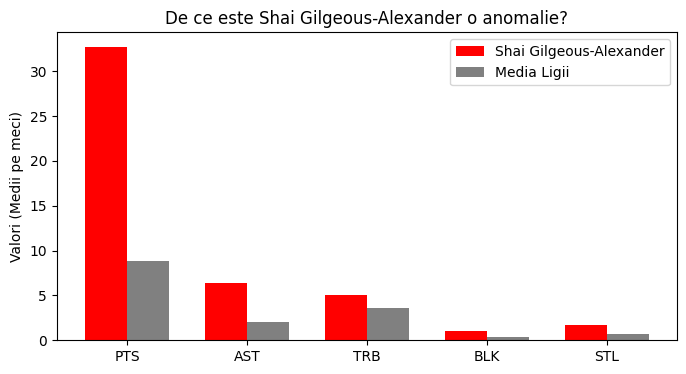


--- ANALIZĂ: Giannis Antetokounmpo ---
Statistica | Valoare Jucător | Media Ligii | Diferență
-------------------------------------------------------
PTS        | 30.4            | 8.9         | +242.1%
AST        | 6.5             | 2.1         | +211.7%
TRB        | 11.9            | 3.6         | +231.0%
BLK        | 1.2             | 0.4         | +197.6%
STL        | 0.9             | 0.7         | +34.6%


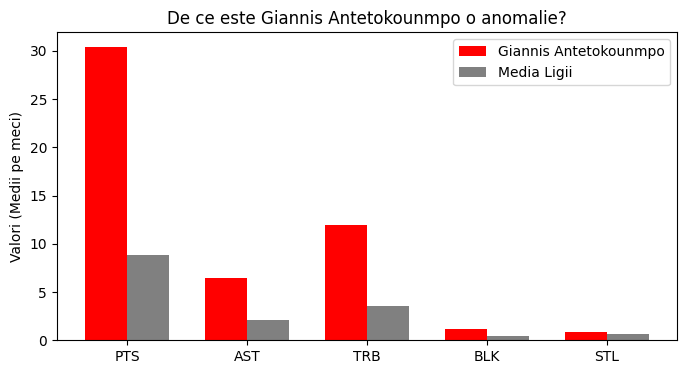


--- ANALIZĂ: Nikola Jokić ---
Statistica | Valoare Jucător | Media Ligii | Diferență
-------------------------------------------------------
PTS        | 29.6            | 8.9         | +233.1%
AST        | 10.2            | 2.1         | +389.2%
TRB        | 12.7            | 3.6         | +253.2%
BLK        | 0.6             | 0.4         | +48.8%
STL        | 1.8             | 0.7         | +169.2%


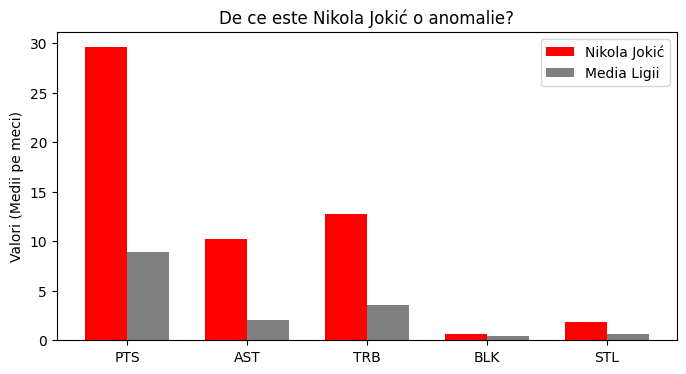

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = ['PTS', 'AST', 'TRB', 'BLK', 'STL']
avg_stats = df[features].mean()

def explain_anomaly(player_name):
    player_stats = df[df['Player'] == player_name][features].iloc[0]

    diff = player_stats - avg_stats
    percent_diff = (diff / avg_stats) * 100

    print(f"\n--- ANALIZĂ: {player_name} ---")
    print(f"Statistica | Valoare Jucător | Media Ligii | Diferență")
    print("-" * 55)
    for feat in features:
        print(f"{feat:<10} | {player_stats[feat]:<15.1f} | {avg_stats[feat]:<11.1f} | {percent_diff[feat]:+.1f}%")

    labels = features
    player_vals = player_stats.values
    avg_vals = avg_stats.values

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    rects1 = ax.bar(x - width/2, player_vals, width, label=player_name, color='red')
    rects2 = ax.bar(x + width/2, avg_vals, width, label='Media Ligii', color='gray')

    ax.set_ylabel('Valori (Medii pe meci)')
    ax.set_title(f'De ce este {player_name} o anomalie?')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    plt.show()

top_3_anomalies = common_anomalies['Player'].head(3).values

for player in top_3_anomalies:
    explain_anomaly(player)

## 9. Concluzii

În urma experimentelor realizate pe setul de date NBA, am ajuns la următoarele concluzii:

1.  **Performanța Algoritmilor:**
    * Conform **scorului Silhouette**, metoda **KNN** a oferit cea mai clară separare a anomaliilor, fiind urmată îndeaproape de Isolation Forest. Acest lucru sugerează că, în cazul statisticilor sportive, anomaliile sunt cel mai bine definite prin *distanța Euclidiană* (magnitudinea performanței) față de restul plutonului.
    * **Indicele Dunn** a avut valori mai mici, ceea ce este normal pentru date continue de performanță sportivă, unde trecerea de la un jucător "bun" la un "superstar" este graduală, nu există o "prăpastie" clară între clustere.

2.  **Consistența și Validarea:**
    * A existat un **consens puternic** între cele trei metode (KNN, ABOD, IForest). Toate au identificat un nucleu comun de jucători (ex: Jokic, Giannis, Doncic).
    * Faptul că anomaliile detectate matematic corespund cu superstarurile recunoscute în realitate validează capacitatea modelului de a funcționa corect fără etichete preexistente.

3.  **Optimizarea:**
    * Analiza de sensibilitate ("Elbow Method") a demonstrat că alegerea unui număr de vecini **k** optim este crucială pentru stabilitatea modelului, evitând detectarea zgomotului ca anomalie.

4.  **Aplicabilitate:**
    * Proiectul demonstrează că tehnicile de *Anomaly Detection* sunt un instrument puternic pentru **scouting automatizat**. Ele pot evidenția rapid jucători cu profiluri excepționale care ar putea fi trecuți cu vederea de o analiză manuală simplă, oferind o bază obiectivă pentru decizii de management sau negociere a contractelor.